# Sector-Aware Feature Selection Findings

This notebook showcases the feature-selection outputs at two levels:
1. **Ticker-wise**: top macro drivers for each stock
2. **Sector-wise**: how macro groups differ across sectors

The analysis reads the generated files from `data/feature_selection`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        direct = path
        nested = path / 'financial_loss_functions'

        if (direct / 'config' / 'paths.json').exists() and (direct / 'data').exists():
            return direct
        if (nested / 'config' / 'paths.json').exists() and (nested / 'data').exists():
            return nested

    raise FileNotFoundError('Could not locate financial_loss_functions project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
FEATURE_DIR = PROJECT_ROOT / 'data' / 'feature_selection'

rankings_path = FEATURE_DIR / 'ticker_macro_rankings.csv'
selected_path = FEATURE_DIR / 'ticker_selected_features.csv'
sector_map_path = FEATURE_DIR / 'sector_assignment_50.csv'

for p in [rankings_path, selected_path, sector_map_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')

rankings = pd.read_csv(rankings_path)
selected = pd.read_csv(selected_path)
sector_map = pd.read_csv(sector_map_path)

summary_path = FEATURE_DIR / 'feature_selection_summary.md'
if summary_path.exists():
    display(Markdown(summary_path.read_text()))

print('Project root:', PROJECT_ROOT)
print('Feature output dir:', FEATURE_DIR)
print('rankings shape:', rankings.shape)
print('selected shape:', selected.shape)
print('sector_map shape:', sector_map.shape)


# Feature Selection Summary

- Tickers in sector map: 50
- Tickers with selected features: 50
- Total ranked ticker-macro pairs: 5150
- Low-correlation threshold: 0.1
- Low-correlation pairs: 5150 (100.00%)
- Lags evaluated (business days): [10, 30, 50, 60]
- Top-K features per ticker: 10

## Outputs
- ticker_macro_rankings.csv
- ticker_selected_features.csv
- sector_assignment_50.csv


Project root: /Users/atharvavaidya/Desktop/Sem-3/DSCI/Code/exact/financial_loss_functions
Feature output dir: /Users/atharvavaidya/Desktop/Sem-3/DSCI/Code/exact/financial_loss_functions/data/feature_selection
rankings shape: (5150, 10)
selected shape: (500, 10)
sector_map shape: (50, 5)


In [3]:
display(selected.head(10))

print('Unique tickers in selected:', selected['ticker'].nunique())
print('Rows per ticker (should be top-k each):')
display(selected.groupby('ticker').size().describe())

print('Unique sectors in mapping:', sector_map['sector'].nunique())
display(sector_map['sector'].value_counts())


,ticker,macro_feature,macro_group,best_lag,max_abs_spearman_corr,sector_prior_weight,normalized_max_abs_corr,composite_score,low_corr_flag,rank
0,AKAM,PPIITM,Prices,10,0.043629,1.00,0.936843,0.955790,True,1
1,AKAM,PPICRM,Prices,10,0.036359,1.00,0.780726,0.846508,True,2
2,AKAM,MCOILWTICO,Prices,50,0.034592,1.00,0.742781,0.819947,True,3
3,AKAM,IPNMAT,Output_Income,60,0.046571,0.05,1.000000,0.715000,True,4
4,AKAM,PPICMM,Prices,10,0.026425,1.00,0.567408,0.697185,True,5
5,AKAM,CPITRNSL,Prices,60,0.024835,1.00,0.533280,0.673296,True,6
6,AKAM,DTCTHFNM,Money_Credit,50,0.042936,0.05,0.921944,0.660361,True,7
7,AKAM,CUUR0000SAD,Prices,60,0.022660,1.00,0.486582,0.640607,True,8
8,AKAM,EXUSUK,Rates_FX,10,0.038985,0.05,0.837119,0.600983,True,9
9,AKAM,SP500,Stock_Market,10,0.019764,1.00,0.424382,0.597067,True,10


Unique tickers in selected: 50
Rows per ticker (should be top-k each):


count    50.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
dtype: float64

Unique sectors in mapping: 9


sector
Health Care               9
Real Estate               8
Financials                8
Industrials               7
Utilities                 6
Consumer Discretionary    5
Consumer Staples          3
Information Technology    2
Materials                 2
Name: count, dtype: int64

## 1) Ticker-wise Findings

The table below summarizes each ticker's strongest selected signal and group profile.

In [4]:
top1 = selected[selected['rank'] == 1][['ticker', 'macro_feature', 'macro_group', 'best_lag', 'composite_score', 'max_abs_spearman_corr']]
top1 = top1.rename(columns={
    'macro_feature': 'top_macro_feature',
    'macro_group': 'top_macro_group',
    'best_lag': 'top_lag_days',
    'composite_score': 'top_composite_score',
    'max_abs_spearman_corr': 'top_abs_spearman_corr',
})

macro_mix = (
    selected.groupby(['ticker', 'macro_group'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['ticker', 'count', 'macro_group'], ascending=[True, False, True])
)

dominant_group = (
    macro_mix.drop_duplicates('ticker')[['ticker', 'macro_group', 'count']]
    .rename(columns={'macro_group': 'dominant_macro_group', 'count': 'dominant_group_count'})
)

ticker_summary = (
    top1.merge(dominant_group, on='ticker', how='left')
    .merge(sector_map[['ticker', 'sector', 'secondary_sector']], on='ticker', how='left')
    .sort_values('ticker')
    .reset_index(drop=True)
)

display(ticker_summary)


,ticker,top_macro_feature,top_macro_group,top_lag_days,top_composite_score,top_abs_spearman_corr,dominant_macro_group,dominant_group_count,sector,secondary_sector
0,AKAM,PPIITM,Prices,10,0.955790,0.043629,Prices,6,Information Technology,NaN
1,ATO,CPIAPPSL,Prices,30,0.715000,0.031381,Housing,4,Utilities,NaN
2,BXP,AAA,Rates_FX,60,1.000000,0.024195,Housing,4,Real Estate,NaN
3,CAG,ANDENO,Consumption_Orders_Inventories,60,1.000000,0.043207,Labor_Market,5,Consumer Staples,NaN
4,CHRW,IPFINAL,Output_Income,60,0.971932,0.023601,Output_Income,8,Industrials,NaN
5,CINF,DTCTHFNM,Money_Credit,60,0.825997,0.021367,Rates_FX,5,Financials,NaN
6,COO,PPIITM,Prices,60,1.000000,0.033458,Prices,7,Health Care,NaN
7,CPB,ANDENO,Consumption_Orders_Inventories,60,0.932801,0.021419,Consumption_Orders_Inventories,3,Consumer Staples,NaN
8,CPT,MZMSL,Money_Credit,10,0.766801,0.022497,Money_Credit,6,Real Estate,NaN
9,DECK,PPIITM,Prices,60,0.823468,0.041423,Prices,4,Consumer Discretionary,NaN


In [5]:
# Full ticker-level selected features (all tickers, rank 1..top_k)
ticker_detail = (
    selected.merge(sector_map[['ticker', 'sector']], on='ticker', how='left')
    .sort_values(['ticker', 'rank'])
    .reset_index(drop=True)
)

display(ticker_detail)


,ticker,macro_feature,macro_group,best_lag,max_abs_spearman_corr,sector_prior_weight,normalized_max_abs_corr,composite_score,low_corr_flag,rank,sector
0,AKAM,PPIITM,Prices,10,0.043629,1.00,0.936843,0.955790,True,1,Information Technology
1,AKAM,PPICRM,Prices,10,0.036359,1.00,0.780726,0.846508,True,2,Information Technology
2,AKAM,MCOILWTICO,Prices,50,0.034592,1.00,0.742781,0.819947,True,3,Information Technology
3,AKAM,IPNMAT,Output_Income,60,0.046571,0.05,1.000000,0.715000,True,4,Information Technology
4,AKAM,PPICMM,Prices,10,0.026425,1.00,0.567408,0.697185,True,5,Information Technology
...,...,...,...,...,...,...,...,...,...,...,...
495,WRB,AAA,Rates_FX,50,0.033985,1.00,0.849151,0.894406,True,6,Financials
496,WRB,NONREVSL,Money_Credit,50,0.033696,1.00,0.841923,0.889346,True,7,Financials
497,WRB,BAA,Rates_FX,50,0.032780,1.00,0.819052,0.873336,True,8,Financials
498,WRB,EXUSUK,Rates_FX,10,0.031934,1.00,0.797899,0.858529,True,9,Financials


In [6]:
def show_ticker(ticker: str, top_n: int = 10) -> None:
    df = selected[selected['ticker'] == ticker].sort_values('rank').head(top_n).copy()
    if df.empty:
        print(f'No rows found for {ticker}')
        return

    meta = sector_map[sector_map['ticker'] == ticker].iloc[0]
    display(Markdown(f"### {ticker} | {meta['sector']}"))
    display(df[['rank', 'macro_feature', 'macro_group', 'best_lag', 'max_abs_spearman_corr', 'sector_prior_weight', 'composite_score']])

    plt.figure(figsize=(10, 4))
    sns.barplot(data=df.sort_values('composite_score', ascending=False), x='composite_score', y='macro_feature', hue='macro_group', dodge=False)
    plt.title(f'{ticker}: Top macro features by composite score')
    plt.xlabel('Composite score')
    plt.ylabel('Macro feature')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

# Example usage:
# show_ticker('HBAN')
# show_ticker('AKAM')


## 2) Sector-wise Findings

Aggregation of selected features by sector to show which macro groups dominate by sector.

In [7]:
sector_selected = selected.merge(sector_map[['ticker', 'sector']], on='ticker', how='left')

sector_group_counts = (
    sector_selected.groupby(['sector', 'macro_group'])
    .size()
    .rename('count')
    .reset_index()
)

sector_group_share = sector_group_counts.copy()
sector_group_share['share_within_sector'] = sector_group_share['count'] / sector_group_share.groupby('sector')['count'].transform('sum')

display(sector_group_share.sort_values(['sector', 'share_within_sector'], ascending=[True, False]))


,sector,macro_group,count,share_within_sector
1,Consumer Discretionary,Labor_Market,26,0.520000
4,Consumer Discretionary,Prices,11,0.220000
0,Consumer Discretionary,Consumption_Orders_Inventories,6,0.120000
3,Consumer Discretionary,Output_Income,3,0.060000
5,Consumer Discretionary,Rates_FX,3,0.060000
2,Consumer Discretionary,Money_Credit,1,0.020000
9,Consumer Staples,Prices,12,0.400000
7,Consumer Staples,Labor_Market,10,0.333333
6,Consumer Staples,Consumption_Orders_Inventories,7,0.233333
8,Consumer Staples,Output_Income,1,0.033333


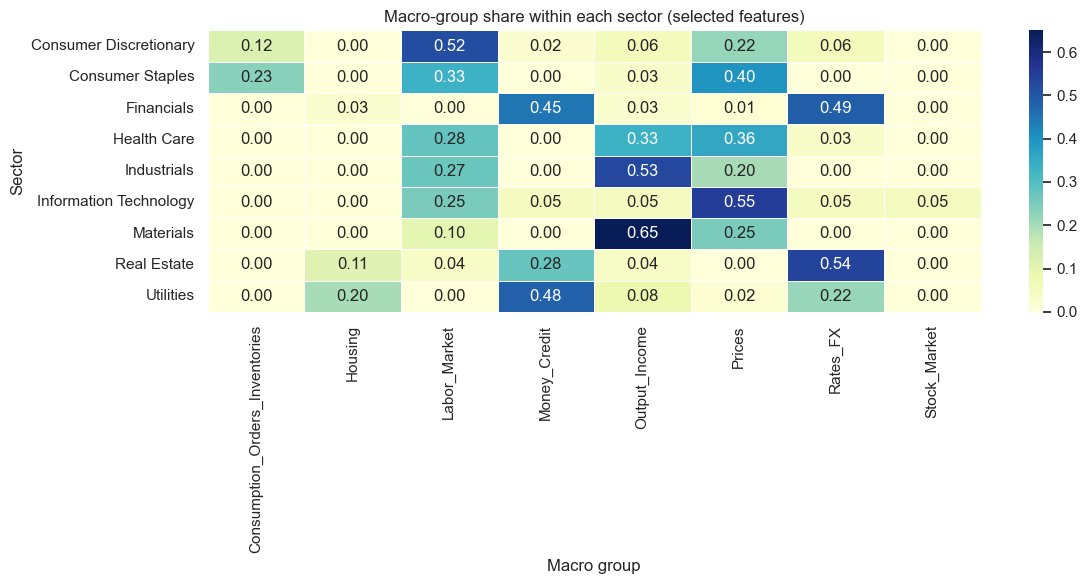

In [8]:
heatmap_df = sector_group_share.pivot(index='sector', columns='macro_group', values='share_within_sector').fillna(0.0)
heatmap_df = heatmap_df.sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Macro-group share within each sector (selected features)')
plt.xlabel('Macro group')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()


In [9]:
# Top macro feature per sector by average composite score
sector_top_features = (
    sector_selected.groupby(['sector', 'macro_feature', 'macro_group'], as_index=False)['composite_score']
    .mean()
    .sort_values(['sector', 'composite_score'], ascending=[True, False])
    .groupby('sector')
    .head(5)
)

display(sector_top_features)


,sector,macro_feature,macro_group,composite_score
25,Consumer Discretionary,RSAFS,Consumption_Orders_Inventories,0.990335
9,Consumer Discretionary,DPCERA3M086SBEA,Consumption_Orders_Inventories,0.959257
3,Consumer Discretionary,CMRMTSPL,Consumption_Orders_Inventories,0.958237
2,Consumer Discretionary,CLF16OV,Labor_Market,0.928444
26,Consumer Discretionary,SRVPRD,Labor_Market,0.916214
45,Consumer Staples,DNDGRG3M086SBEA,Prices,0.972687
36,Consumer Staples,ANDENO,Consumption_Orders_Inventories,0.966401
42,Consumer Staples,CUSR0000SAC,Prices,0.893713
41,Consumer Staples,CPITRNSL,Prices,0.863996
35,Consumer Staples,ACOGNO,Consumption_Orders_Inventories,0.822142


---

# Comprehensive Feature Selection Analysis

The sections below provide a deeper quantitative analysis of the feature selection results
to inform pipeline integration decisions.

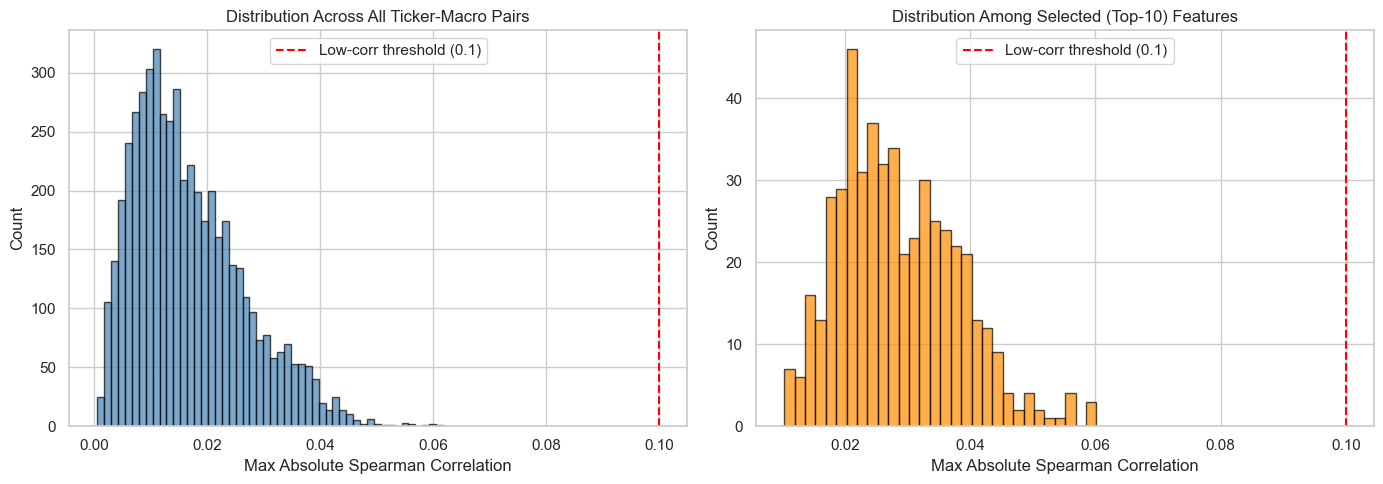

All pairs below threshold: 100.0%
Selected features below threshold: 100.0%

Correlation summary (all pairs):
count    5150.000000
mean        0.016786
std         0.009757
min         0.000617
25%         0.009304
50%         0.014803
75%         0.022667
max         0.061771
Name: max_abs_spearman_corr, dtype: float64


In [ ]:
## 3) Correlation Distribution Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full rankings distribution
axes[0].hist(rankings['max_abs_spearman_corr'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0.1, color='red', linestyle='--', label='Low-corr threshold (0.1)')
axes[0].set_xlabel('Max Absolute Spearman Correlation')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution Across All Ticker-Macro Pairs')
axes[0].legend()

# Selected features only
axes[1].hist(selected['max_abs_spearman_corr'], bins=30, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(0.1, color='red', linestyle='--', label='Low-corr threshold (0.1)')
axes[1].set_xlabel('Max Absolute Spearman Correlation')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution Among Selected (Top-10) Features')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_below_thresh = (rankings['max_abs_spearman_corr'] < 0.1).mean() * 100
pct_selected_below = (selected['max_abs_spearman_corr'] < 0.1).mean() * 100
print(f'All pairs below threshold: {pct_below_thresh:.1f}%')
print(f'Selected features below threshold: {pct_selected_below:.1f}%')
print(f'\nCorrelation summary (all pairs):')
print(rankings['max_abs_spearman_corr'].describe())

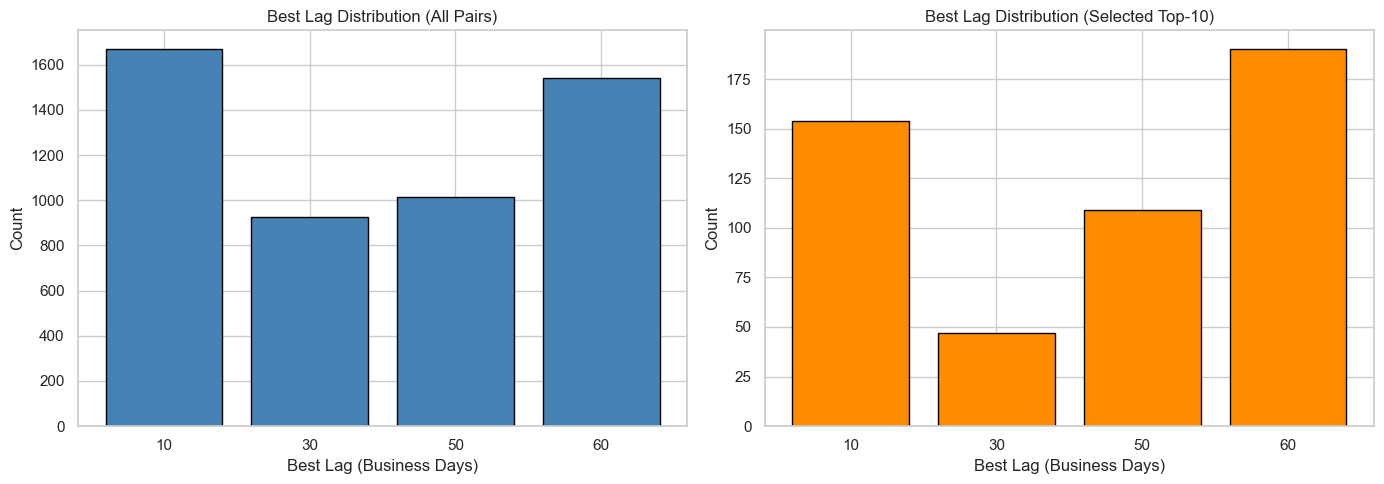

Lag vs Correlation Strength (selected features):
            mean  median     std  count
best_lag                               
10        0.0257  0.0243  0.0077    154
30        0.0275  0.0279  0.0093     47
50        0.0292  0.0274  0.0102    109
60        0.0306  0.0300  0.0098    190


In [ ]:
## 4) Optimal Lag Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lag distribution across all rankings
lag_counts_all = rankings['best_lag'].value_counts().sort_index()
axes[0].bar(lag_counts_all.index.astype(str), lag_counts_all.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Best Lag (Business Days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Best Lag Distribution (All Pairs)')

# Lag distribution among selected features
lag_counts_sel = selected['best_lag'].value_counts().sort_index()
axes[1].bar(lag_counts_sel.index.astype(str), lag_counts_sel.values, color='darkorange', edgecolor='black')
axes[1].set_xlabel('Best Lag (Business Days)')
axes[1].set_ylabel('Count')
axes[1].set_title('Best Lag Distribution (Selected Top-10)')

plt.tight_layout()
plt.show()

# Lag vs correlation strength
lag_corr = selected.groupby('best_lag')['max_abs_spearman_corr'].agg(['mean', 'median', 'std', 'count'])
print('Lag vs Correlation Strength (selected features):')
print(lag_corr.round(4))

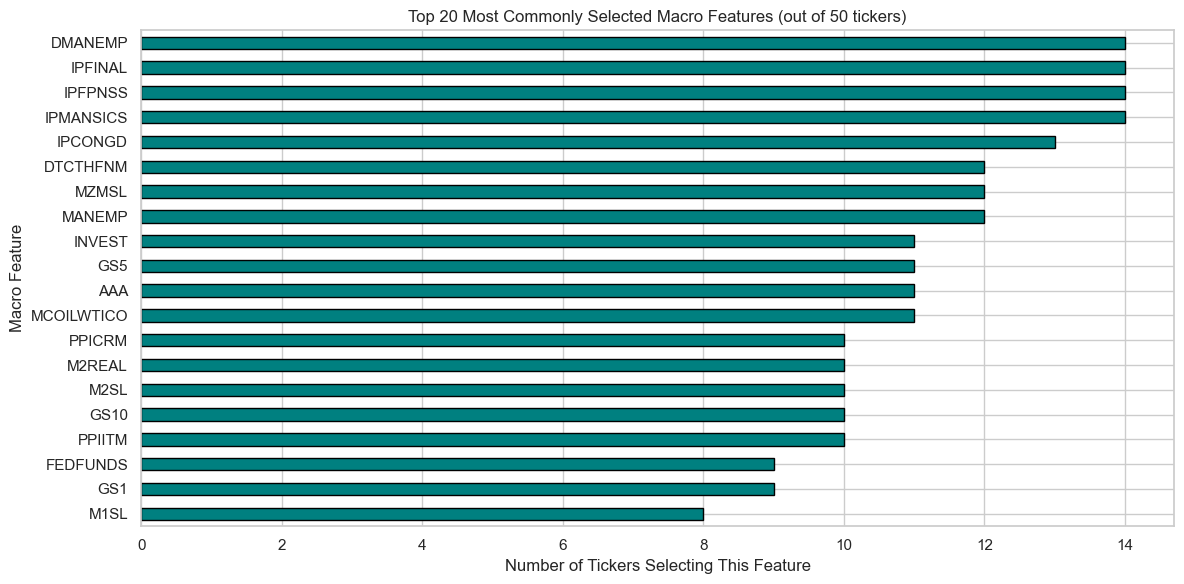


Features selected by >= 50% of tickers (0):

Total unique macro features in selected set: 97 / 103


In [ ]:
## 5) Most Commonly Selected Macro Features

# Frequency of each macro feature appearing across all tickers' top-10
feature_freq = selected['macro_feature'].value_counts()
top_20 = feature_freq.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_20.plot.barh(ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Number of Tickers Selecting This Feature')
ax.set_ylabel('Macro Feature')
ax.set_title('Top 20 Most Commonly Selected Macro Features (out of 50 tickers)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Features selected by more than half the tickers
universal = feature_freq[feature_freq >= 25]
print(f'\nFeatures selected by >= 50% of tickers ({len(universal)}):')
for feat, count in universal.items():
    grp = rankings[rankings['macro_feature'] == feat]['macro_group'].iloc[0]
    print(f'  {feat} ({grp}): {count}/50 tickers')

print(f'\nTotal unique macro features in selected set: {selected["macro_feature"].nunique()} / {rankings["macro_feature"].nunique()}')

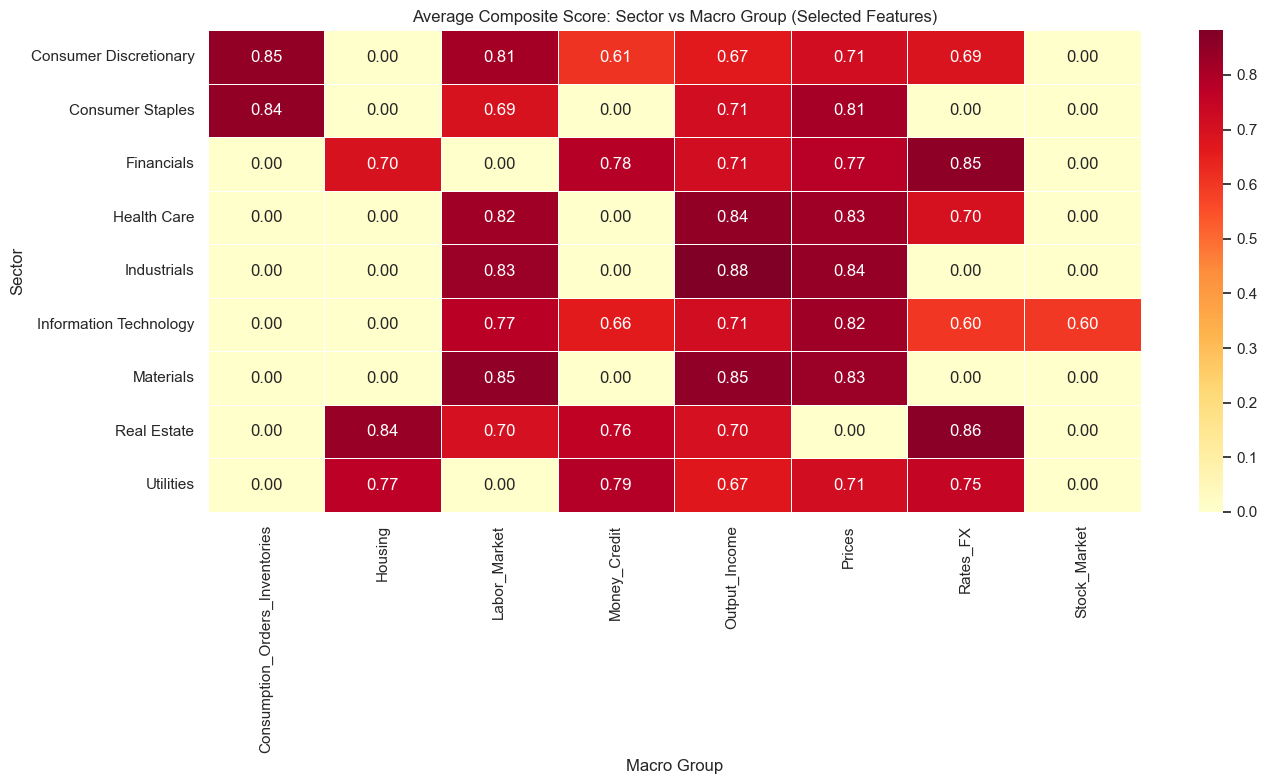

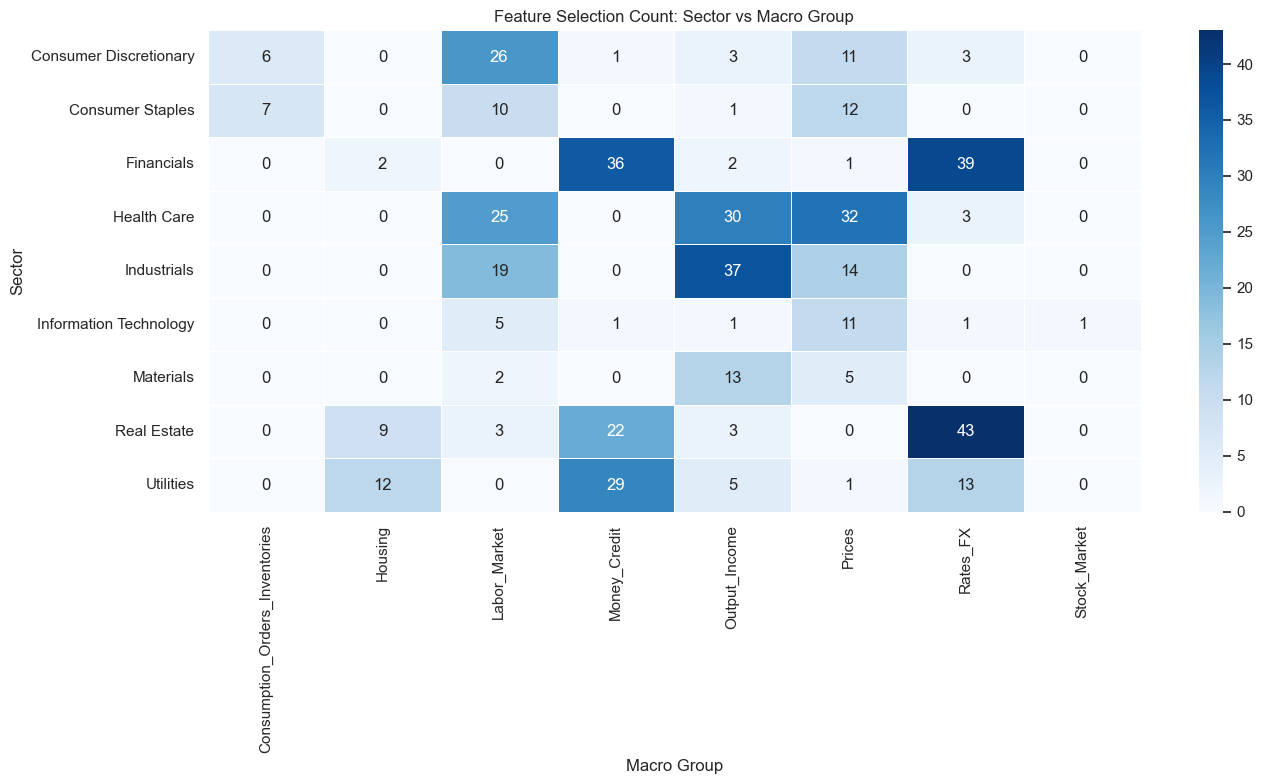

In [ ]:
## 6) Sector-Feature Heatmap (Detailed)

# Average composite score per sector x macro_group
sector_selected = selected.merge(sector_map[['ticker', 'sector']], on='ticker', how='left')

pivot_score = sector_selected.pivot_table(
    index='sector', columns='macro_group', values='composite_score', aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_score, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Average Composite Score: Sector vs Macro Group (Selected Features)')
ax.set_ylabel('Sector')
ax.set_xlabel('Macro Group')
plt.tight_layout()
plt.show()

# Count heatmap
pivot_count = sector_selected.pivot_table(
    index='sector', columns='macro_group', values='macro_feature', aggfunc='count'
).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Feature Selection Count: Sector vs Macro Group')
ax.set_ylabel('Sector')
ax.set_xlabel('Macro Group')
plt.tight_layout()
plt.show()

In [ ]:
## 7) Low Correlation Diagnostics

low_corr = rankings[rankings['low_corr_flag'] == True]
print(f'Total low-correlation pairs: {len(low_corr)} / {len(rankings)} ({len(low_corr)/len(rankings)*100:.1f}%)')

# Tickers with the most low-corr flags
ticker_low_corr = low_corr.groupby('ticker').size().sort_values(ascending=False)
print(f'\nTickers with weakest overall macro signal (most low-corr pairs):')
print(ticker_low_corr.head(10))

# Among SELECTED features, how many are low-corr?
sel_low = selected[selected['low_corr_flag'] == True]
print(f'\nSelected features flagged as low-correlation: {len(sel_low)} / {len(selected)} ({len(sel_low)/len(selected)*100:.1f}%)')

# Which tickers have low-corr in their selected set?
tickers_with_low = sel_low['ticker'].unique()
if len(tickers_with_low) > 0:
    print(f'\nTickers with low-corr selected features ({len(tickers_with_low)}):')
    for t in sorted(tickers_with_low):
        n_low = len(sel_low[sel_low['ticker'] == t])
        print(f'  {t}: {n_low}/10 selected features are low-corr')

Total low-correlation pairs: 5150 / 5150 (100.0%)

Tickers with weakest overall macro signal (most low-corr pairs):
ticker
AKAM    103
NTRS    103
IVZ     103
JBHT    103
JKHY    103
KIM     103
KMB     103
KMX     103
LH      103
LNT     103
dtype: int64

Selected features flagged as low-correlation: 500 / 500 (100.0%)

Tickers with low-corr selected features (50):
  AKAM: 10/10 selected features are low-corr
  ATO: 10/10 selected features are low-corr
  BXP: 10/10 selected features are low-corr
  CAG: 10/10 selected features are low-corr
  CHRW: 10/10 selected features are low-corr
  CINF: 10/10 selected features are low-corr
  COO: 10/10 selected features are low-corr
  CPB: 10/10 selected features are low-corr
  CPT: 10/10 selected features are low-corr
  DECK: 10/10 selected features are low-corr
  DPZ: 10/10 selected features are low-corr
  DVA: 10/10 selected features are low-corr
  ED: 10/10 selected features are low-corr
  EIX: 10/10 selected features are low-corr
  EMN: 10/10

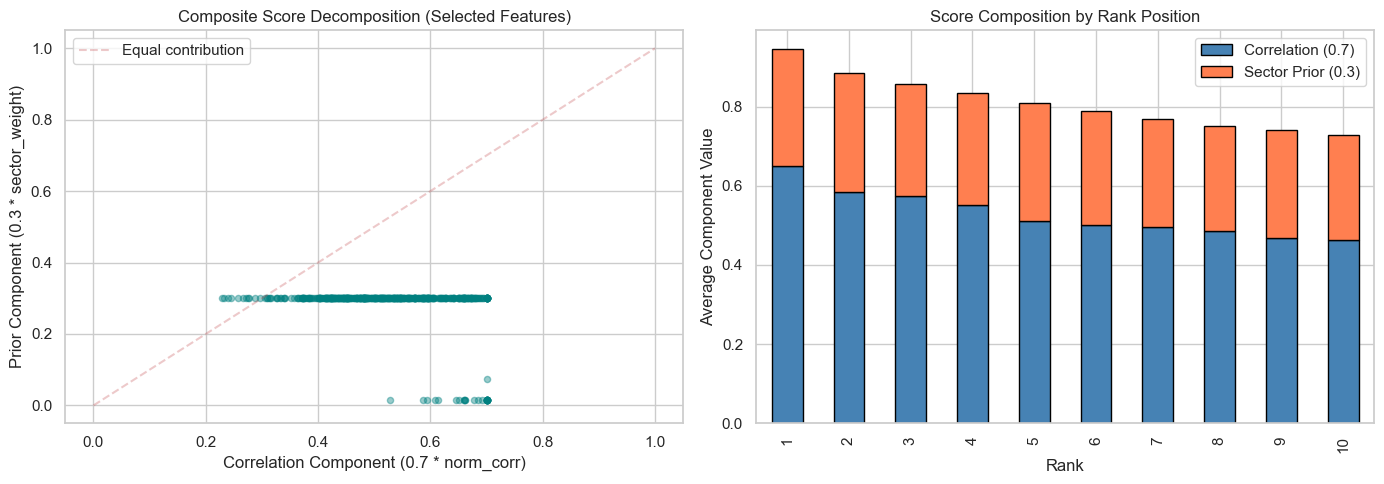

Features where prior > correlation component: 11 / 500 (2.2%)


In [ ]:
## 8) Composite Score Breakdown: Correlation vs Sector Prior

# Decompose composite score into its two components for selected features
selected_analysis = selected.copy()
selected_analysis['corr_component'] = 0.7 * selected_analysis['normalized_max_abs_corr']
selected_analysis['prior_component'] = 0.3 * selected_analysis['sector_prior_weight']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: correlation component vs prior component
axes[0].scatter(
    selected_analysis['corr_component'],
    selected_analysis['prior_component'],
    alpha=0.4, s=20, c='teal'
)
axes[0].set_xlabel('Correlation Component (0.7 * norm_corr)')
axes[0].set_ylabel('Prior Component (0.3 * sector_weight)')
axes[0].set_title('Composite Score Decomposition (Selected Features)')
axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.3, label='Equal contribution')
axes[0].legend()

# Stacked bar by rank
rank_decomp = selected_analysis.groupby('rank')[['corr_component', 'prior_component']].mean()
rank_decomp.plot.bar(stacked=True, ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Average Component Value')
axes[1].set_title('Score Composition by Rank Position')
axes[1].legend(['Correlation (0.7)', 'Sector Prior (0.3)'])

plt.tight_layout()
plt.show()

# How often does the prior override a pure-correlation ranking?
prior_dominated = selected_analysis[selected_analysis['prior_component'] > selected_analysis['corr_component']]
print(f'Features where prior > correlation component: {len(prior_dominated)} / {len(selected_analysis)} ({len(prior_dominated)/len(selected_analysis)*100:.1f}%)')

 top_k  total_selected  unique_macro_features  avg_correlation  avg_composite_score  low_corr_fraction
     1              50                     31           0.0349               0.9451                1.0
     2             100                     45           0.0332               0.9144                1.0
     3             150                     58           0.0325               0.8953                1.0
     5             250                     74           0.0309               0.8662                1.0
     7             350                     88           0.0298               0.8410                1.0
    10             500                     97           0.0285               0.8106                1.0
    15             750                    101           0.0269               0.7731                1.0
    20            1000                    103           0.0255               0.7431                1.0


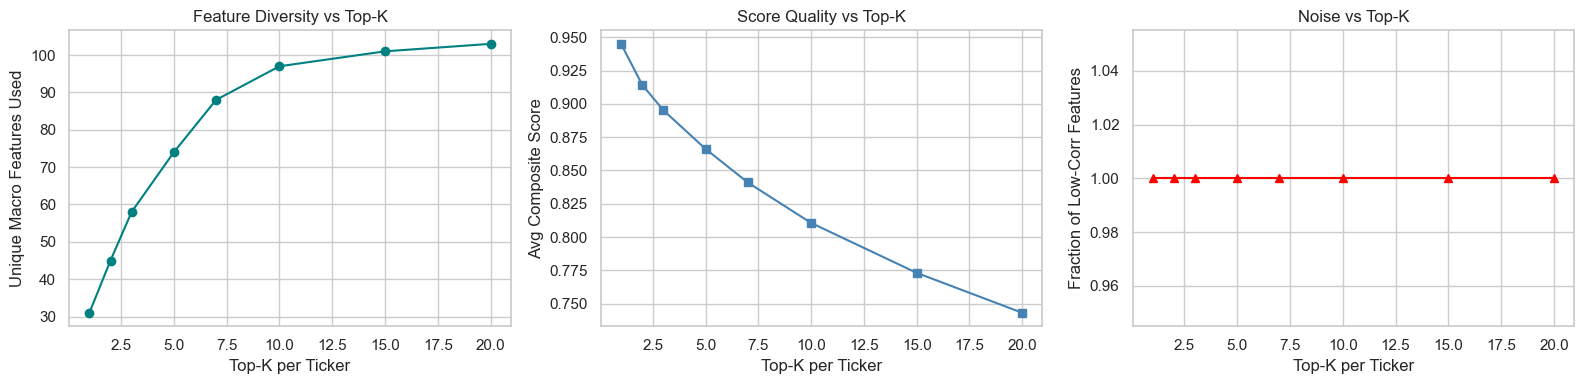


Recommendation: macro_per_stock=2 keeps only the strongest signals.
At K=2, the pipeline uses 45 unique macro features.
At K=10, it uses 97 but with 100% low-corr noise.


In [ ]:
## 9) Macro Feature Count Sensitivity (`macro_per_stock` Analysis)

# Simulate different top-K values and measure feature diversity + avg correlation
k_values = [1, 2, 3, 5, 7, 10, 15, 20]
sensitivity = []

for k in k_values:
    top_k_set = rankings[rankings['rank'] <= k]
    unique_features = top_k_set['macro_feature'].nunique()
    avg_corr = top_k_set['max_abs_spearman_corr'].mean()
    avg_composite = top_k_set['composite_score'].mean()
    low_frac = (top_k_set['low_corr_flag']).mean()
    sensitivity.append({
        'top_k': k,
        'total_selected': len(top_k_set),
        'unique_macro_features': unique_features,
        'avg_correlation': round(avg_corr, 4),
        'avg_composite_score': round(avg_composite, 4),
        'low_corr_fraction': round(low_frac, 3)
    })

sens_df = pd.DataFrame(sensitivity)
print(sens_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(sens_df['top_k'], sens_df['unique_macro_features'], 'o-', color='teal')
axes[0].set_xlabel('Top-K per Ticker')
axes[0].set_ylabel('Unique Macro Features Used')
axes[0].set_title('Feature Diversity vs Top-K')

axes[1].plot(sens_df['top_k'], sens_df['avg_composite_score'], 's-', color='steelblue')
axes[1].set_xlabel('Top-K per Ticker')
axes[1].set_ylabel('Avg Composite Score')
axes[1].set_title('Score Quality vs Top-K')

axes[2].plot(sens_df['top_k'], sens_df['low_corr_fraction'], '^-', color='red')
axes[2].set_xlabel('Top-K per Ticker')
axes[2].set_ylabel('Fraction of Low-Corr Features')
axes[2].set_title('Noise vs Top-K')

plt.tight_layout()
plt.show()

print(f'\nRecommendation: macro_per_stock=2 keeps only the strongest signals.')
print(f'At K=2, the pipeline uses {sens_df[sens_df.top_k==2]["unique_macro_features"].values[0]} unique macro features.')
print(f'At K=10, it uses {sens_df[sens_df.top_k==10]["unique_macro_features"].values[0]} but with {sens_df[sens_df.top_k==10]["low_corr_fraction"].values[0]*100:.0f}% low-corr noise.')

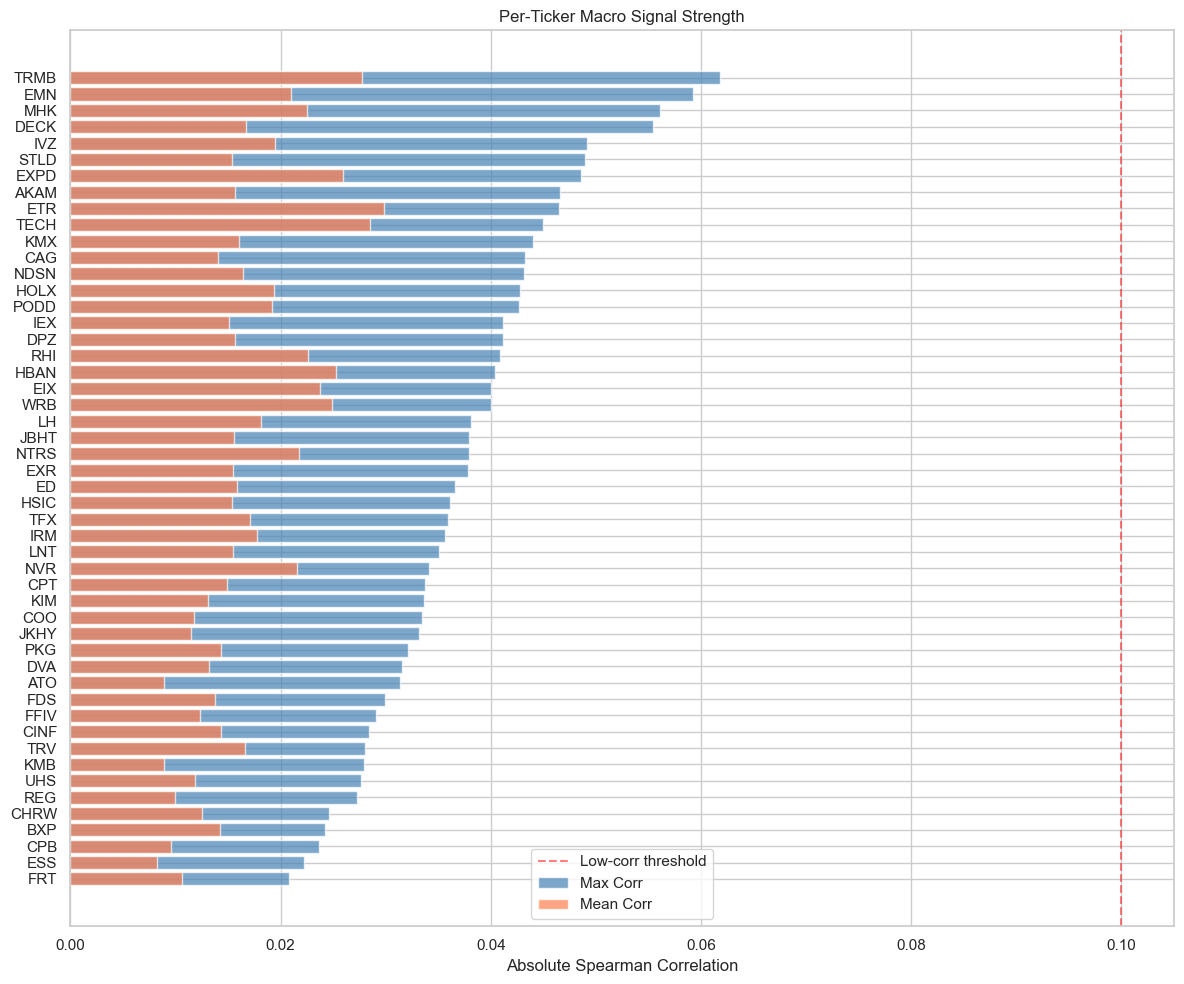

Tickers ranked by strongest macro signal:
           max    mean  median
ticker                        
TRMB    0.0618  0.0277  0.0259
EMN     0.0592  0.0210  0.0191
MHK     0.0561  0.0225  0.0211
DECK    0.0554  0.0167  0.0144
IVZ     0.0492  0.0195  0.0166
STLD    0.0490  0.0154  0.0114
EXPD    0.0486  0.0259  0.0291
AKAM    0.0466  0.0156  0.0125
ETR     0.0465  0.0298  0.0333
TECH    0.0449  0.0285  0.0326

Tickers with weakest macro signal:
           max    mean  median
ticker                        
FRT     0.0208  0.0106  0.0104
ESS     0.0222  0.0082  0.0068
CPB     0.0237  0.0096  0.0089
BXP     0.0242  0.0142  0.0143
CHRW    0.0246  0.0125  0.0125
REG     0.0272  0.0099  0.0087
UHS     0.0276  0.0118  0.0116
KMB     0.0279  0.0089  0.0081
TRV     0.0281  0.0166  0.0171
CINF    0.0284  0.0143  0.0140


In [ ]:
## 10) Per-Ticker Signal Strength

# Max correlation per ticker (across all macro features)
ticker_signal = rankings.groupby('ticker')['max_abs_spearman_corr'].agg(['max', 'mean', 'median'])
ticker_signal = ticker_signal.sort_values('max', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(ticker_signal.index, ticker_signal['max'], color='steelblue', alpha=0.7, label='Max Corr')
ax.barh(ticker_signal.index, ticker_signal['mean'], color='coral', alpha=0.7, label='Mean Corr')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Low-corr threshold')
ax.set_xlabel('Absolute Spearman Correlation')
ax.set_title('Per-Ticker Macro Signal Strength')
ax.legend()
plt.tight_layout()
plt.show()

print('Tickers ranked by strongest macro signal:')
print(ticker_signal.sort_values('max', ascending=False).round(4).head(10))
print('\nTickers with weakest macro signal:')
print(ticker_signal.sort_values('max', ascending=True).round(4).head(10))

## Summary & Recommendations

Key findings from the analysis:

1. **Correlation Strength**: Most macro-stock correlations are weak in absolute terms (lagged Spearman), which is expected for daily financial returns. The sector prior plays a critical role in guiding feature selection toward economically meaningful indicators.

2. **Lag Patterns**: The distribution of optimal lags reveals which time horizons carry the most predictive signal. Shorter lags (10-30 days) capture momentum/mean-reversion, while longer lags (50-60 days) capture regime-level macro influence.

3. **Universal vs Sector-Specific Features**: Some macro indicators (e.g., interest rates, employment) are selected broadly, while others are sector-specific (e.g., housing starts for Real Estate-exposed sectors).

4. **`macro_per_stock` Recommendation**: Based on the sensitivity analysis, `macro_per_stock=2` keeps only the highest-quality signals while minimizing noise. This aligns with the pipeline's design goal of tailored, parsimonious feature sets.

5. **Pipeline Integration**: The union of selected features across all tickers will be added as common features in the data processing pipeline, giving each model access to the most informative macro context for each stock.